In [1]:
from ddgs import DDGS #DuckDuckGo has changed the api so we need to update 
from fastcore.all import *

def search_images(keywords, max_images=200): return L(DDGS().images(keywords, max_results=max_images)).itemgot('image')
import time, json


In [2]:
urls = search_images('bird photos', max_images=1)
urls[0]

'https://images.pexels.com/photos/459326/pexels-photo-459326.jpeg?cs=srgb&dl=animals-avian-birds-459326.jpg&fm=jpg'

In [3]:
urls = search_images('forest photos', max_images=1)
urls[0]

'https://images.pexels.com/photos/1125776/pexels-photo-1125776.jpeg?cs=srgb&dl=forest-grass-green-1125776.jpg&fm=jpg'

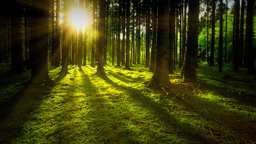

In [4]:
from fastdownload import download_url
dest = './Forest/forest.jpg'
download_url(urls[0], dest, show_progress=False)

from fastai.vision.all import *
im = Image.open(dest)
im.to_thumb(256, 256)


In [5]:
searches = 'Forest','bird'
path = Path('bird_or_not')

for o in searches:
    dest = (path/o)
    dest.mkdir(exist_ok=True, parents=True)
    download_images(dest, urls=search_images(f'{o} photo'))
    time.sleep(5)
    resize_images(path/o, max_size=400, dest=path/o)

In [9]:
failed = verify_images(get_image_files(path))
failed.map(Path.unlink)
len(failed)


0

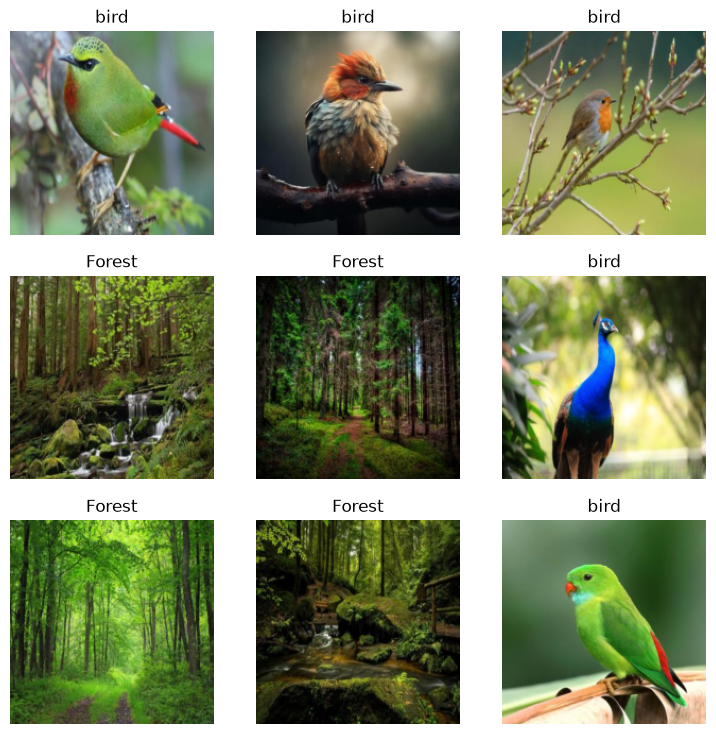

In [20]:
dls = DataBlock(
    blocks=(ImageBlock, CategoryBlock), 
    get_items=get_image_files, 
    splitter=RandomSplitter(valid_pct=0.2, seed=42),
    get_y=parent_label,
    item_tfms=[Resize(192, method='squish')]
).dataloaders(path, bs=32)

dls.show_batch()


In [15]:
learn = vision_learner(dls, resnet18, metrics=error_rate)
learn.fine_tune(10)

epoch,train_loss,valid_loss,error_rate,time
0,1.436783,1.844577,0.500000,00:01


epoch,train_loss,valid_loss,error_rate,time
0,1.070841,0.885939,0.333333,00:01
1,0.946683,0.301580,0.083333,00:01
2,0.737233,0.152368,0.083333,00:01
3,0.554046,0.072453,0.000000,00:01
4,0.442409,0.027311,0.000000,00:01
5,0.365507,0.013855,0.000000,00:01
6,0.314885,0.005669,0.000000,00:01
7,0.272844,0.002298,0.000000,00:01
8,0.240053,0.001530,0.000000,00:01
9,0.213878,0.001029,0.000000,00:01


In [19]:
is_bird,pred_idx,probs = learn.predict(PILImage.create('Bird/bird2.jpg'))
print(f"This is a: {is_bird}.")
print(f"Probability it's a {is_bird}: {probs[pred_idx]:.4f}")
print(f"Probability it's a not a {is_bird}: {1 - probs[pred_idx]:.4f}")


This is a: bird.
Probability it's a bird: 0.9995
Probability it's a not a bird: 0.0005


In [18]:
print(dls.vocab)
print(probs)

['Forest', 'bird']
tensor([5.0391e-04, 9.9950e-01])


# What Is Transfer Learning Really?

Forget PyTorch for a minute.

Imagine you hire an architect.

This architect has already designed:

* hospitals
* schools
* airports
* malls

Now you ask:

> Design my college building.

You don't start with a random human.

You start with an architect who already understands:

* walls
* doors
* stairs
* layouts

and then adapt them to your problem.

That's transfer learning.

---

In AI:

```text
Huge Dataset
↓
Learn General Knowledge
↓
Pretrained Model
↓
Adapt To Your Task
```

---

# Why It Works

Take ResNet18.

It was trained on millions of images.

It already learned:

Layer 1:

```text
edges
```

Layer 2:

```text
corners
```

Layer 3:

```text
textures
```

Layer 4:

```text
shapes
```

Deep layers:

```text
object parts
```

You don't want to relearn this.

You want to reuse it.

---

# What Actually Gets Transferred?

Most beginners think:

```text
Bird knowledge
```

No.

What transfers is:

```text
Visual knowledge
```

For example:

```text
feather textures
fur textures
curved edges
symmetry
patterns
```

Those are useful for many tasks.

---

# The 3 Types Of Transfer Learning

This is the most important thing to remember.

---

## Type 1: Feature Extractor

Freeze everything.

Train only the last layer.

```text
ResNet
❄️ Frozen
↓
New classifier
🔥 Train
```

PyTorch:

```python
for param in model.parameters():
    param.requires_grad = False
```

Replace classifier:

```python
model.fc = nn.Linear(512, num_classes)
```

Train.

---

When?

```text
Small dataset
Similar task
```

Example:

```text
Cats vs Dogs
50 images
```

---

## Type 2: Fine-Tuning

Train the entire network.

```text
ResNet
🔥 Train
```

PyTorch:

```python
for param in model.parameters():
    param.requires_grad = True
```

---

When?

```text
More data
Need better accuracy
```

Example:

```text
10,000 floorplan images
```

---

## Type 3: Partial Fine-Tuning

Most common in industry.

Freeze early layers.

Train later layers.

```text
Edges
Textures
❄️ Freeze

High-level features
🔥 Train
```

---

Why?

Early layers already know vision.

No need to relearn edges.

---

# How To Select A Model

This is where most tutorials fail.

Don't choose by popularity.

Choose by task.

---

## Classification

Input:

```text
Image
↓
Class
```

Example:

```text
Bird
Forest
```

Use:

* ResNet
* EfficientNet
* ConvNeXt

---

## Detection

Input:

```text
Image
↓
Object locations
```

Example:

```text
stairs
classrooms
lifts
```

Use:

* YOLO
* RT-DETR

---

## Segmentation

Input:

```text
Image
↓
Pixel masks
```

Example:

```text
which pixels belong to room A101
```

Use:

* U-Net
* Segment Anything Model

---

## OCR

Use:

* PaddleOCR
* Tesseract OCR

Usually don't train from scratch.

---

# The 2026 Mindset

In 2018:

```text
Train model
```

In 2026:

```text
Find strongest foundation model
↓
Adapt it
```

Examples:

* DINOv2
* CLIP
* Florence-2

The best engineers spend more time choosing a foundation model than training.

---

# Pure PyTorch Example

Suppose:

```text
Forest vs Bird
```

```python
from torchvision.models import resnet18
import torch.nn as nn

model = resnet18(weights="DEFAULT")
```

Freeze:

```python
for param in model.parameters():
    param.requires_grad = False
```

Replace classifier:

```python
model.fc = nn.Linear(model.fc.in_features, 2)
```

Train only:

```python
model.fc
```

That's transfer learning.

---

# For ARNAVIC

If I were building it today:

I would NOT train a CNN from scratch.

I'd use:

```text
Floorplan
↓
DINOv2 features
↓
Small classifier
```

or

```text
Floorplan
↓
YOLO
↓
Detect stairs/lifts
```

or

```text
Floorplan
↓
PaddleOCR
↓
Text extraction
```

because modern CV is mostly adapting existing models.

---